#### Edit cache phase 1 status to run from step 2-> 4

In [4]:
import json
import os
import re
from collections import defaultdict

# --- Config ---
status_path = r"E:\Work Spaces\Thesis\Code\ThesisMaster\phase1\phase1_status.json"
new_root    = r"E:\Work Spaces\Thesis\Data\SiCH_v2\output_52_55_58_100_cut_500f"

cli_input_folder  = r"E:\Work Spaces\Thesis\Data\SiCH_v2\input"
cli_output_folder = new_root
cli_predict_folder = r"E:\Work Spaces\Thesis\Data\SiCH_v2\predict_112"

num_of_hidro = ["52", "55", "58", "100"]
min_len_data = 0

# --- Load status ---
with open(status_path, "r", encoding="utf-8") as f:
    data = json.load(f)

# --- Header ---
data["input_folder"]  = cli_input_folder
data["output_folder"] = cli_output_folder
data["predict_folder"] = cli_predict_folder

# --- Step flags ---
data.setdefault("phase1", {}).setdefault("step_1", {})
data["phase1"]["step_1"]["success"] = True

for k in ["step_2", "step_3", "step_4"]:
    data["phase1"].setdefault(k, {})
    data["phase1"][k]["success"] = False
    for kk in [
        "new_training_file", "config_training_file", "epochs",
        "model_path", "framework", "model_mtime", "image_loss"
    ]:
        data["phase1"][k].pop(kk, None)

# --- Rebuild FOLDER_COMBINE from new_root ---
pat = re.compile(r'^(training|validation)_data_(\d+)(?:_.+)?$', re.IGNORECASE)
required = {"box.npy", "coord.npy", "energy.npy", "force.npy", "virial.npy"}

train_dict, val_dict = defaultdict(list), defaultdict(list)

for name in os.listdir(new_root):
    sys_dir = os.path.join(new_root, name)
    if not os.path.isdir(sys_dir):
        continue

    m = pat.match(name)
    if not m:
        continue

    split = m.group(1).lower()  # training | validation
    key   = m.group(2)          # e.g. "100"

    set000 = os.path.join(sys_dir, "set.000")
    if not os.path.isdir(set000):
        continue

    try:
        files_in = set(os.listdir(set000))
    except Exception:
        continue

    if not required.issubset(files_in):
        continue

    if split == "training":
        train_dict[key].append(sys_dir)
    else:
        val_dict[key].append(sys_dir)

for d in (train_dict, val_dict):
    for k in d:
        d[k] = sorted(d[k])

data["phase1"]["step_1"]["FOLDER_COMBINE"] = [dict(train_dict), dict(val_dict)]

# --- TYPE_MAP (list[str]) and params ---
def detect_type_map_list(root: str):
    for name in os.listdir(root):
        fp = os.path.join(root, name, "type_map.raw")
        if os.path.exists(fp):
            with open(fp, "r", encoding="utf-8") as f:
                lst = [line.strip() for line in f if line.strip()]
                if lst:
                    return lst
    return None

type_map_list = detect_type_map_list(new_root) or ["Si", "C", "H"]
data["phase1"]["step_1"]["TYPE_MAP"] = type_map_list

data["phase1"]["step_1"]["params"] = {
    "num_of_hidro": num_of_hidro,
    "min_len_data": min_len_data
}

# --- Save ---
with open(status_path, "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2, ensure_ascii=False)

print("phase1_status.json updated.")


phase1_status.json updated.


#### Cut-off index for output 

✅ Done. Wrote to: E:\Work Spaces\Thesis\Data\SiCH_v2\output_52_55_58_100_cut_500f
   Total matched system folders: 76
   Processed: 76, Skipped: 0


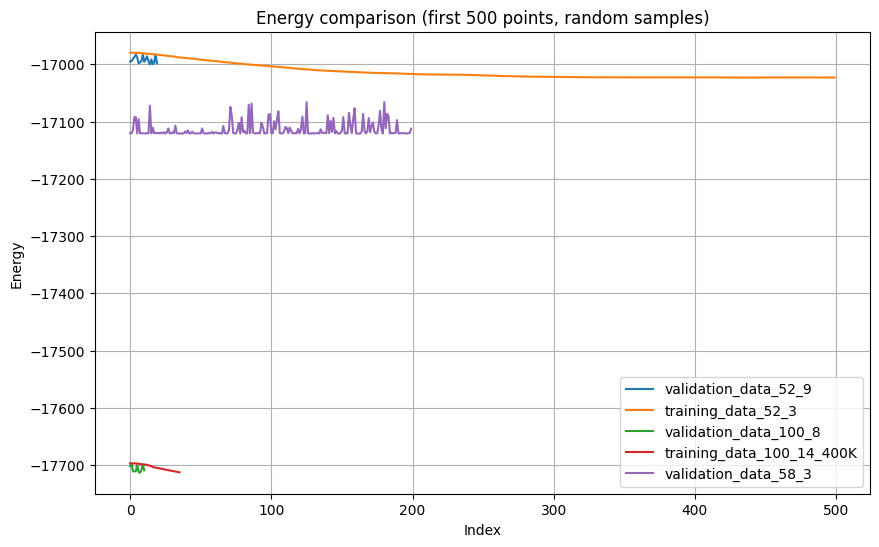

box.npy (4, 9)
coord.npy (4, 636)
energy.npy (4, 1)
force.npy (4, 636)
virial.npy (4, 9)


In [ ]:
import os
import re
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIG ---
# Root folder of original (uncut) data
input_root  = r"E:\Work Spaces\Thesis\Data\SiCH_v2\output_52_55_58_100"
# Root folder to write the cut version
output_root = r"E:\Work Spaces\Thesis\Data\SiCH_v2\output_52_55_58_100_cut_500f"
# Max frames to keep along axis 0
MAX_FRAMES = 500

# System folder name pattern (supports suffixes like _13_400K, _v2, etc.)
pat = re.compile(r'^(training|validation)_data_\d+(?:_.+)?$', re.IGNORECASE)

# Files we will slice along axis 0
npy_files = ["box.npy", "coord.npy", "energy.npy", "force.npy", "virial.npy"]

os.makedirs(output_root, exist_ok=True)

def cut_first_axis(arr, max_frames):
    """Return arr[:max_frames] along axis 0 (or arr if shorter)."""
    if arr.ndim == 0:
        # Should not happen for these npy files, but keep safe
        return arr
    n = min(arr.shape[0], max_frames)
    return np.array(arr[:n])  # ensure materialized (not memmap)

total_dirs = 0
processed_dirs = 0
skipped_dirs = 0

for subdir in os.listdir(input_root):
    in_dir = os.path.join(input_root, subdir)
    if not os.path.isdir(in_dir):
        continue

    # Only process training_data_* or validation_data_* folders
    if not pat.match(subdir):
        # Uncomment if you want to see which ones are skipped:
        # print(f"[skip] Not a system folder: {subdir}")
        continue

    total_dirs += 1

    in_set = os.path.join(in_dir, "set.000")
    if not os.path.isdir(in_set):
        print(f"Missing set.000: {in_set}")
        skipped_dirs += 1
        continue

    out_dir = os.path.join(output_root, subdir)
    out_set = os.path.join(out_dir, "set.000")
    os.makedirs(out_set, exist_ok=True)

    # 1) Copy type files at the same level as set.000
    for fname in ("type.raw", "type_map.raw"):
        src = os.path.join(in_dir, fname)
        dst = os.path.join(out_dir, fname)
        if os.path.exists(src):
            try:
                # Copy only if missing; overwrite=False can be changed to True if you want to refresh
                if not os.path.exists(dst):
                    shutil.copy2(src, dst)
            except Exception as e:
                print(f"Cannot copy {fname} from '{src}' to '{dst}': {e}")
        else:
            print(f"Source {fname} not found: {src}")

    # 2) Slice npy files to MAX_FRAMES
    ok_any = False
    for fname in npy_files:
        in_file  = os.path.join(in_set, fname)
        out_file = os.path.join(out_set, fname)

        if not os.path.exists(in_file):
            print(f"File not found: {in_file}")
            continue

        try:
            # Use memmap to reduce RAM usage on large arrays
            data = np.load(in_file, mmap_mode="r")
            data_cut = cut_first_axis(data, MAX_FRAMES)
            np.save(out_file, data_cut)
            ok_any = True
        except Exception as e:
            print(f"Failed processing '{in_file}': {e}")

    if ok_any:
        processed_dirs += 1
    else:
        skipped_dirs += 1

print(f"   Done. Wrote to: {output_root}")
print(f"   Total matched system folders: {total_dirs}")
print(f"   Processed: {processed_dirs}, Skipped: {skipped_dirs}")

# --- Quick visualization on random samples from the CUT output ---
# Collect system folders from the CUT root
subdirs = [d for d in os.listdir(output_root) if os.path.isdir(os.path.join(output_root, d)) and pat.match(d)]

if len(subdirs) == 0:
    print(" No system folders found in output root to plot.")
else:
    # Sample up to 5 folders to plot energy
    sample_subdirs = random.sample(subdirs, min(5, len(subdirs)))
    plt.figure(figsize=(10, 6))

    for subdir in sample_subdirs:
        energy_file = os.path.join(output_root, subdir, "set.000", "energy.npy")
        if not os.path.exists(energy_file):
            print(f" Missing file: {energy_file}")
            continue
        energy = np.load(energy_file)
        n_points = min(energy.shape[0], MAX_FRAMES)
        plt.plot(range(n_points), energy[:n_points], label=subdir)

    plt.xlabel("Index")
    plt.ylabel("Energy")
    plt.title(f"Energy comparison (first {MAX_FRAMES} points, random samples)")
    plt.legend()
    plt.grid(True)
    plt.show()
    
check_dir = os.path.join(output_root, subdirs[0], "set.000")
for f in npy_files:
    p = os.path.join(check_dir, f)
    if os.path.exists(p):
        arr = np.load(p)
        print(f, arr.shape)

In [ ]:
import os, numpy as np, re

output_root = r"E:\Work Spaces\Thesis\Data\SiCH_v2\output_52_55_58_100_cut_500f"
pat = re.compile(r'^(training|validation)_data_\d+(?:_.+)?$', re.IGNORECASE)
files = ["box.npy", "coord.npy", "energy.npy", "force.npy", "virial.npy"]

ok = bad = 0
eq500 = 0
missing_type = []

for d in os.listdir(output_root):
    if not pat.match(d): 
        continue
    sys_dir = os.path.join(output_root, d)
    set_dir = os.path.join(sys_dir, "set.000")
    if not os.path.isdir(set_dir):
        print("  Missing set.000:", set_dir); bad += 1; continue

    shapes = {}
    try:
        for f in files:
            p = os.path.join(set_dir, f)
            if not os.path.exists(p):
                raise FileNotFoundError(p)
            a = np.load(p)
            shapes[f] = a.shape
        # check same n_frames on axis 0
        n0s = {s[0] for s in shapes.values()}
        if len(n0s) != 1:
            print(" Frame mismatch:", d, shapes); bad += 1; continue
        n0 = n0s.pop()
        if n0 == 500: 
            eq500 += 1
        if n0 > 500:
            print(" More than 500 frames:", d, shapes); bad += 1; continue
        ok += 1
    except Exception as e:
        print(" Error in", d, "->", e); bad += 1

    # check type files (cùng cấp set.000)
    for tf in ("type.raw", "type_map.raw"):
        if not os.path.exists(os.path.join(sys_dir, tf)):
            missing_type.append((d, tf))

print(f"\nSummary: OK={ok}, Bad={bad}, Exactly_500={eq500}")
if missing_type:
    print("  Missing type files:")
    for d, tf in missing_type[:10]:
        print("  ", d, ":", tf)
    if len(missing_type) > 10:
        print(f"  ... and {len(missing_type)-10} more")



Summary: OK=76, Bad=0, Exactly_500=22


#### Read data to visual energy distribution

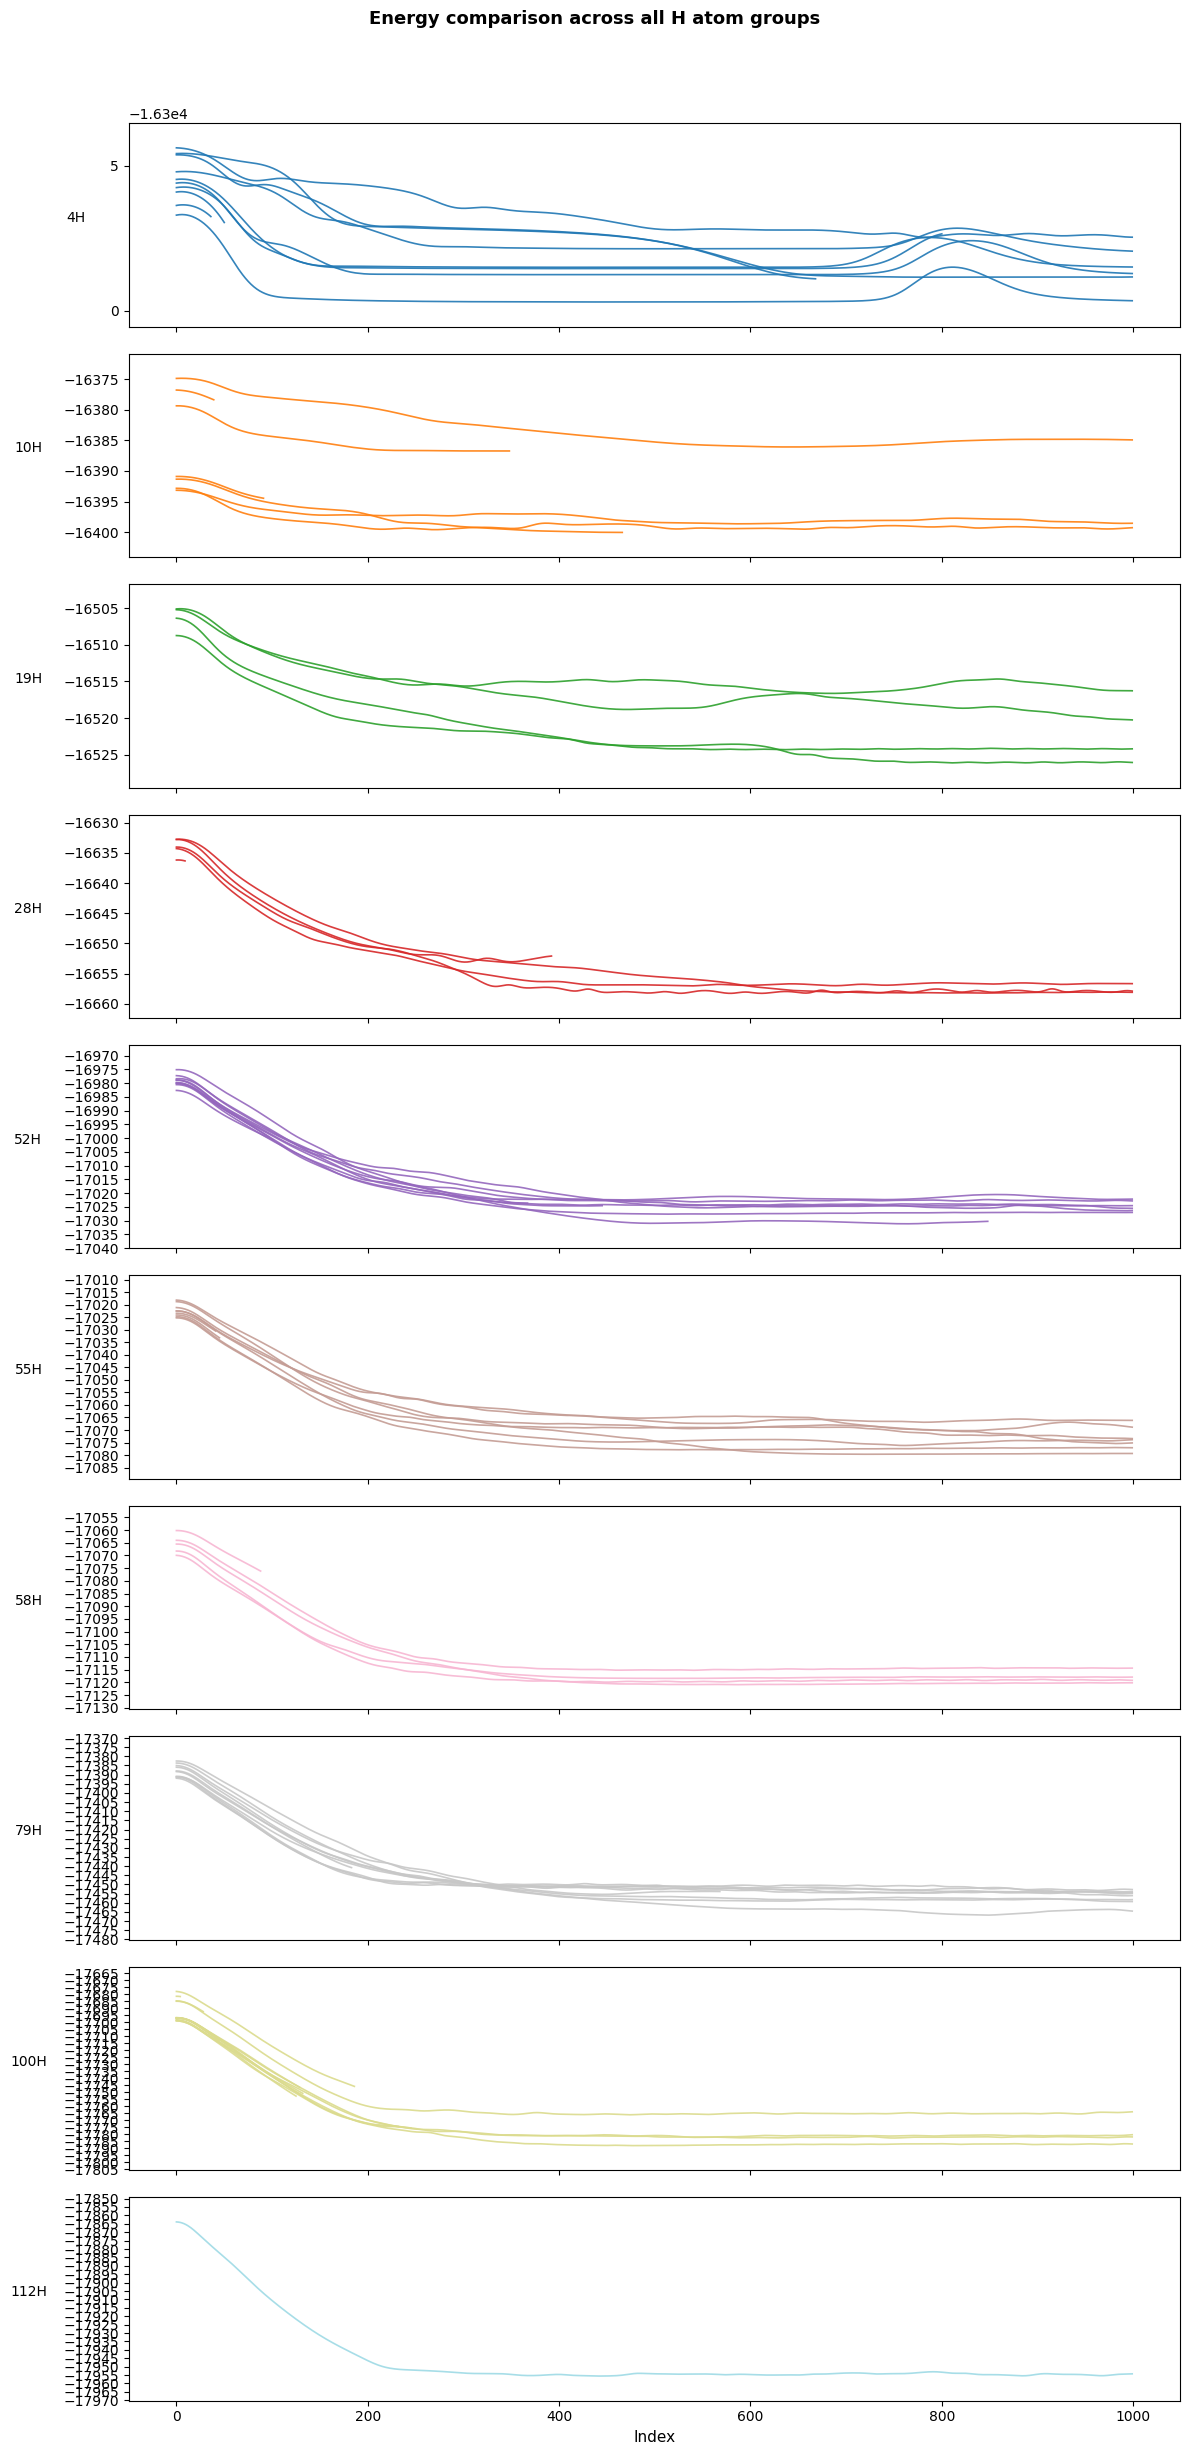

In [5]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

root = Path(r"E:\Work Spaces\Thesis\Data\SiCH_v2\input\result")

# --- Thu thập các đường cong năng lượng ---
draw = {}
for e in root.glob("prediction_data_*/set.000/energy.npy"):
    run_dir = e.parents[1].name
    if run_dir.startswith("prediction_data_"):
        key = run_dir[len("prediction_data_"):]
    else:
        continue
    try:
        draw[key] = np.load(e)
    except Exception:
        continue

# --- Gom nhóm theo prefix trước dấu "_" ---
final = {}
for k, v in draw.items():
    idx = k.split("_", 1)[0]
    final.setdefault(idx, {})[k] = v

def natural_key(s: str):
    return [int(t) if t.isdigit() else t for t in re.split(r"(\d+)", s)]

# --- Tạo subplot cho từng nhóm ---
n_groups = len(final)
fig, axes = plt.subplots(n_groups, 1, figsize=(12, 2.5 * n_groups), sharex=True)

# Đảm bảo axes là list (kể cả khi chỉ có 1 nhóm)
if n_groups == 1:
    axes = [axes]

# Gán màu riêng cho từng nhóm
colors = plt.cm.tab20(np.linspace(0, 1, n_groups))
color_map = {idx: colors[i % len(colors)] for i, idx in enumerate(sorted(final, key=natural_key))}

for ax, (idx, runs) in zip(axes, sorted(final.items(), key=lambda x: int(x[0]))):
    color = color_map[idx]
    for name in sorted(runs, key=natural_key):
        ax.plot(runs[name], color=color, alpha=0.9, linewidth=1.2)
    ax.set_ylabel(f"{idx}H", rotation=0, labelpad=25, fontsize=10)
    ax.yaxis.set_major_locator(MultipleLocator(5))
    ax.grid(False)
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin - 0.1 * (ymax - ymin), ymax + 0.1 * (ymax - ymin))

axes[-1].set_xlabel("Index", fontsize=11)
fig.suptitle("Energy comparison across all H atom groups", fontsize=13, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


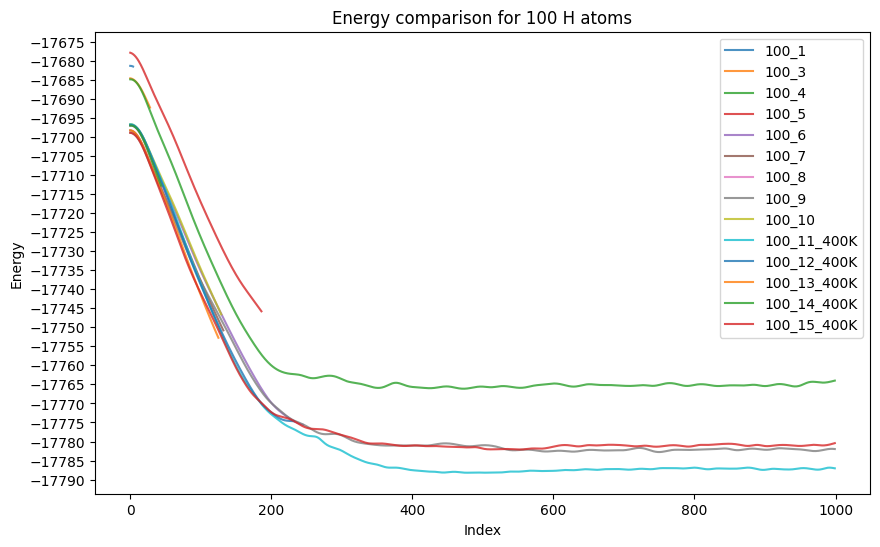

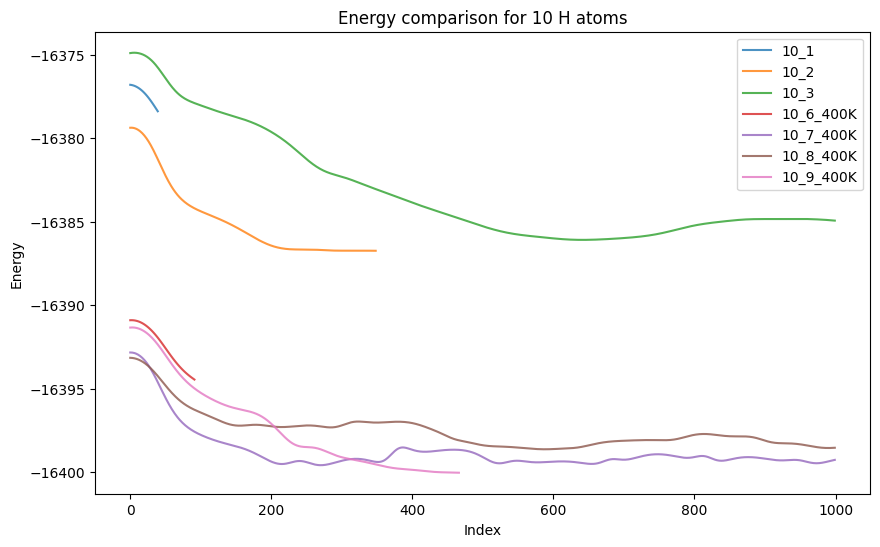

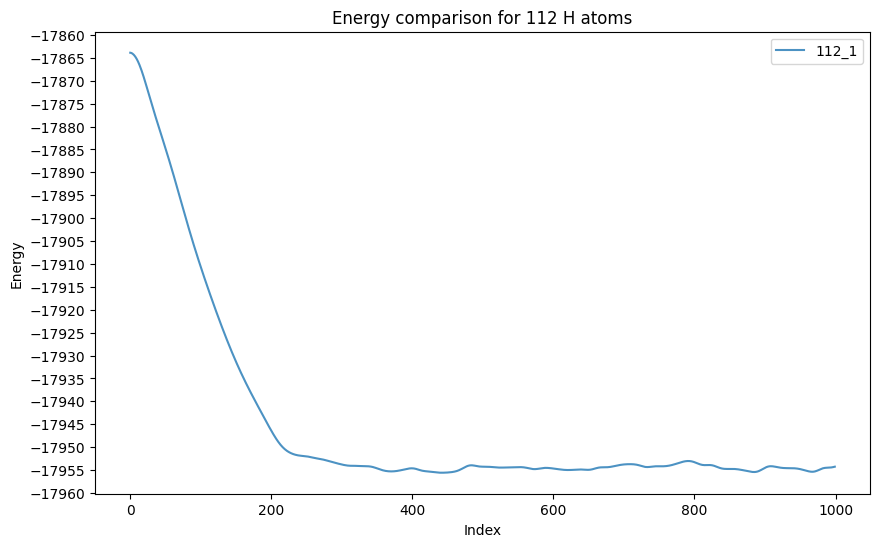

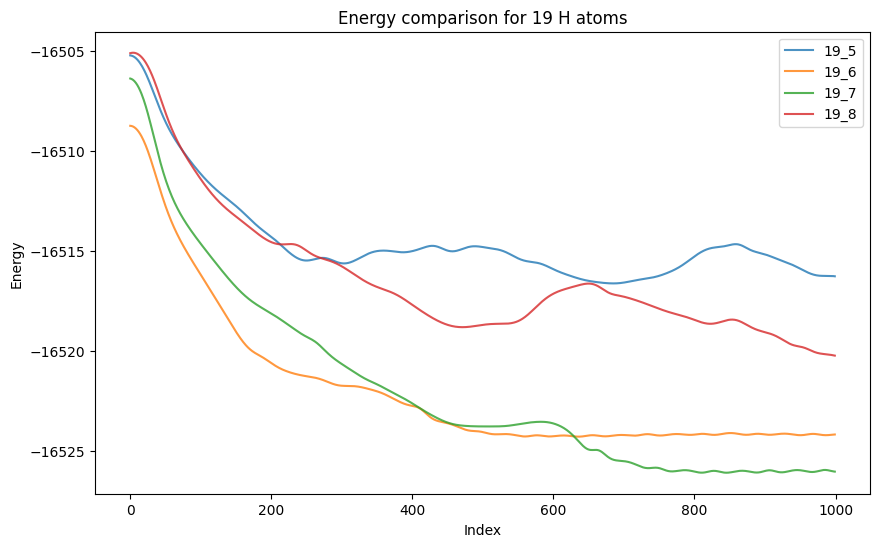

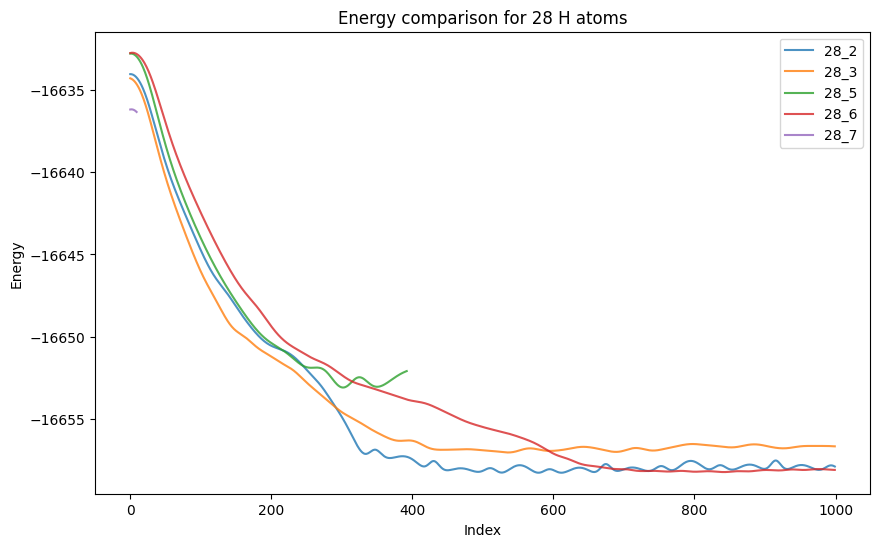

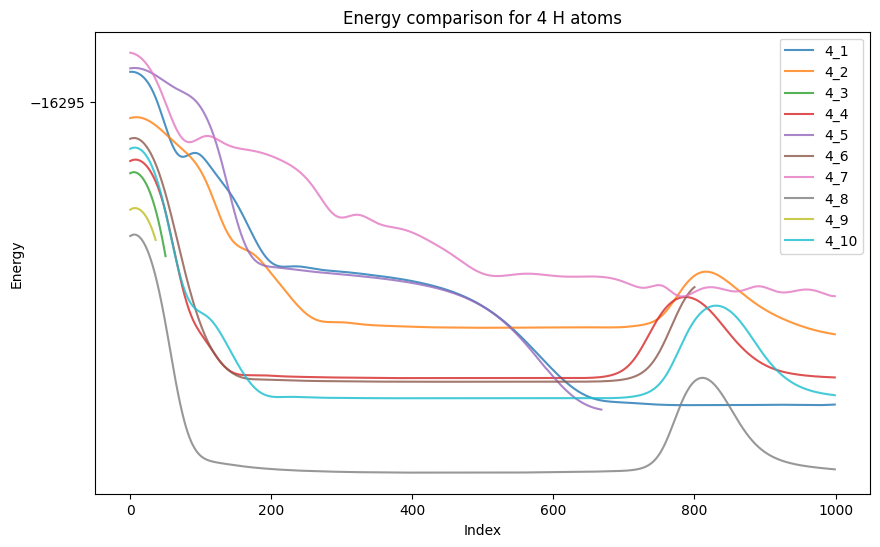

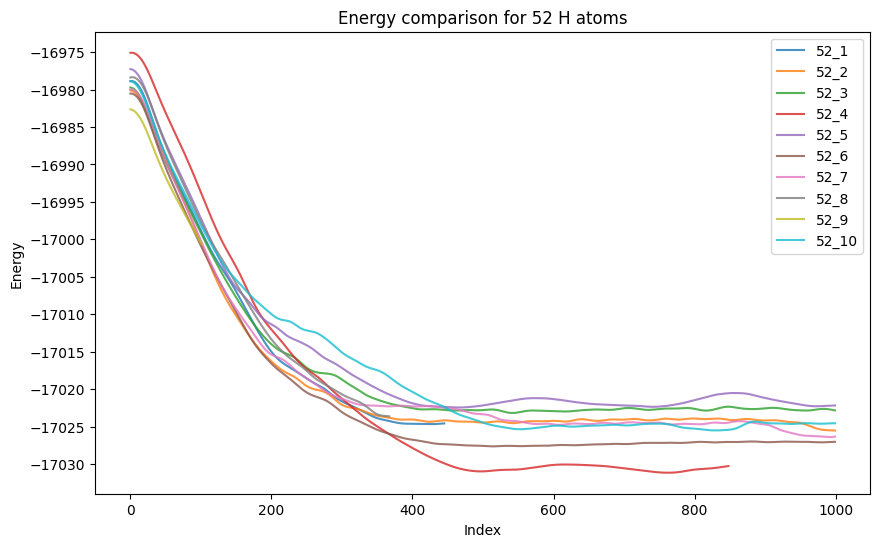

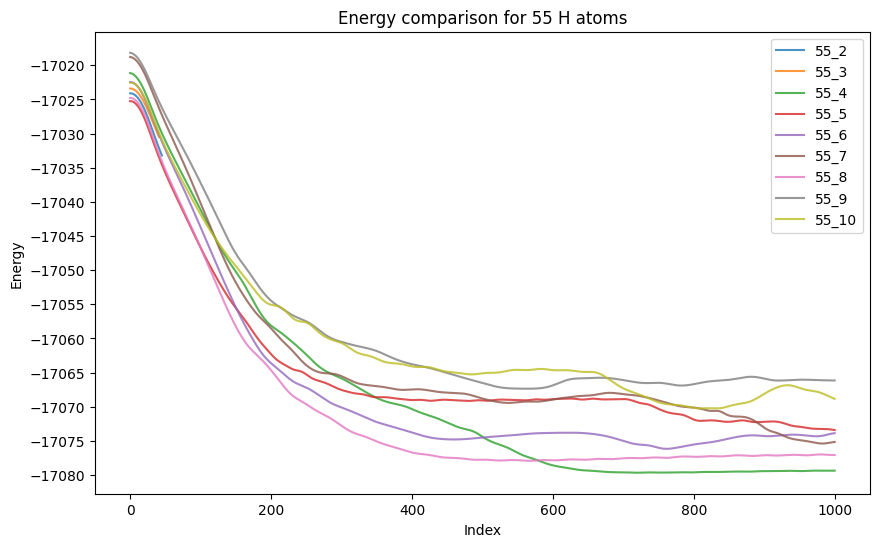

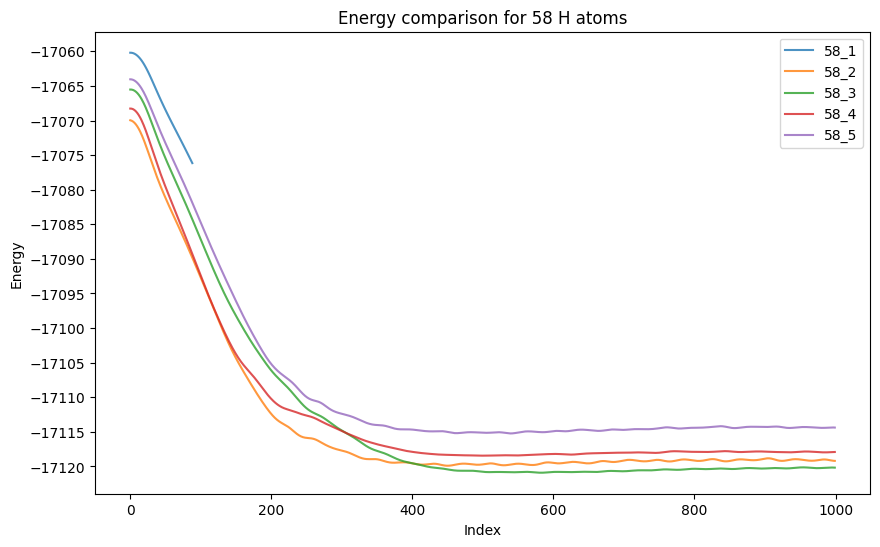

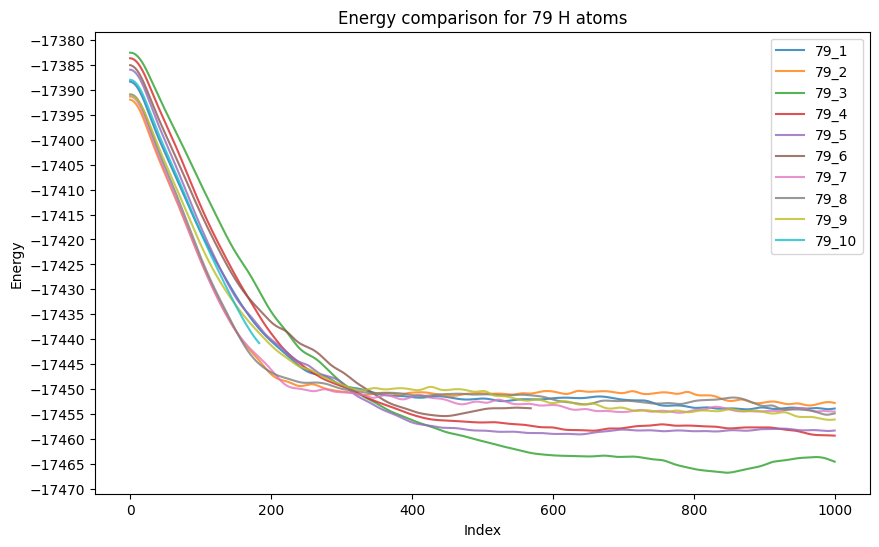

In [39]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

root = Path(r"E:\Work Spaces\Thesis\Data\SiCH_v2\input\result")

# Thu thập các đường cong năng lượng
draw = {}
for e in root.glob("prediction_data_*/set.000/energy.npy"):
    run_dir = e.parents[1].name  # "prediction_data_100_11_400K"
    if run_dir.startswith("prediction_data_"):
        key = run_dir[len("prediction_data_"):]
    else:
        # dự phòng: bỏ qua hoặc dùng nguyên tên
        # key = run_dir
        continue
    try:
        draw[key] = np.load(e)
    except Exception:
        continue

# Gom nhóm theo prefix trước dấu "_"
final = {}
for k, v in draw.items():
    idx = k.split("_", 1)[0]
    final.setdefault(idx, {})[k] = v

def natural_key(s: str):
    return [int(t) if t.isdigit() else t for t in re.split(r"(\d+)", s)]

# Vẽ
for idx, runs in final.items():
    plt.figure(figsize=(10, 6))
    for name in sorted(runs, key=natural_key):
        plt.plot(runs[name], label=name, alpha=0.8, linewidth=1.5)
    plt.xlabel("Index"); plt.ylabel("Energy")
    plt.title(f"Energy comparison for {idx} H atoms")
    plt.legend(loc="best"); plt.grid(False)
    plt.gca().yaxis.set_major_locator(MultipleLocator(5))
    plt.show()


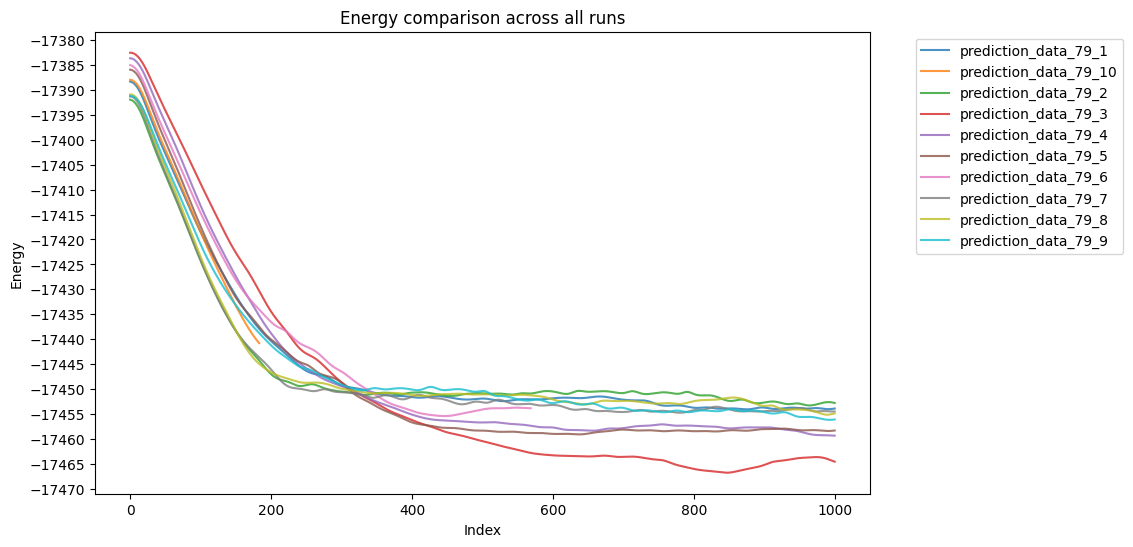

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

path = r"E:\Work Spaces\Thesis\Data\SiCH_v2\predict\result"

plt.figure(figsize=(10,6))  # create one figure

for f in os.listdir(path):
    energy = os.path.join(path, f, "set.000", "energy.npy")
    if os.path.exists(energy):
        data = np.load(energy)
        plt.plot(data, label=f, alpha=0.8, linewidth=1.5)


plt.xlabel("Index")
plt.ylabel("Energy")
plt.title("Energy comparison across all runs")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(False)
plt.gca().yaxis.set_major_locator(MultipleLocator(5))
plt.show()


#### Convert from output.out to raw

In [ ]:
import dpdata

sys = dpdata.LabeledSystem("output.out", fmt="siesta/aimd_output")
sys.to("deepmd/raw", "dataset_siesta_raw")

#### Convert from output.out to npy

In [ ]:
import dpdata

sys = dpdata.LabeledSystem("output.out", fmt="siesta/aimd_output")
sys.to("deepmd/npy", "dataset_siesta_npy")

#### Convert from npy to raw

In [ ]:
import dpdata

sys = dpdata.LabeledSystem("training_data", fmt="deepmd/npy")
sys.to("deepmd/raw", "dataset_raw")

#### Read log to visual data distribution

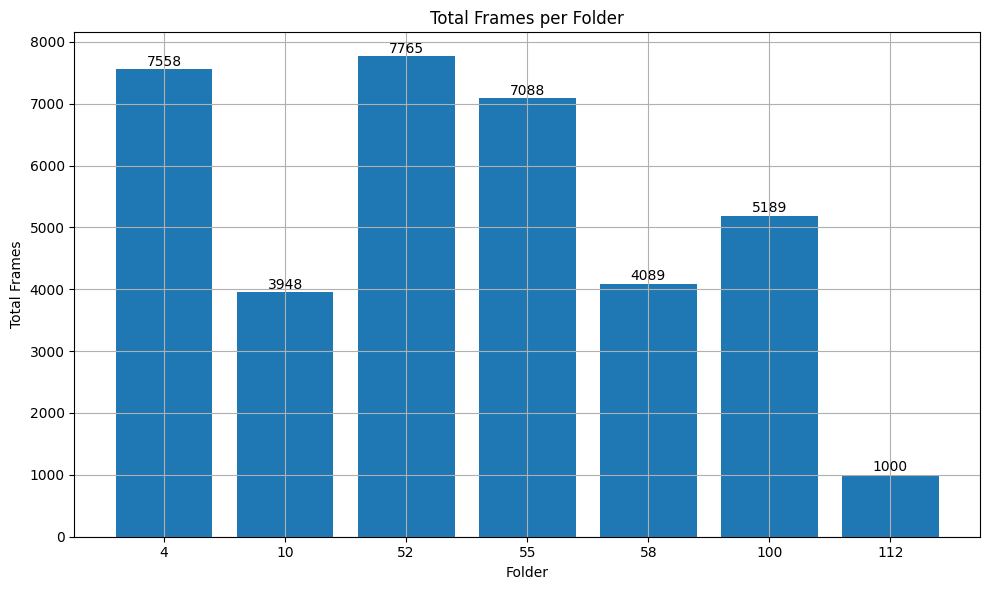

In [1]:
import re
import matplotlib.pyplot as plt
from collections import defaultdict

# List of folders to be analyzed
target_folders = {'4', '10', '52', '55', '58', '100', '112'}
frame_counts = defaultdict(int)

# Read log file
with open(r'E:\Work Spaces\Thesis\Code\ThesisMaster\logs\2025-09-12_22-18-59\log.txt', 'r', encoding='utf-8') as f:
    lines = f.readlines()

# Iterate through each line
for i in range(len(lines) - 1):
    line = lines[i].strip()

    # Match lines that contain input folder path
    match = re.search(r"input\\(\d+)", line)
    if match:
        folder_id = match.group(1)
        if folder_id in target_folders:
            next_line = lines[i + 1].strip()
            # Check if next line contains frame information
            frame_match = re.search(r"the data contains (\d+) frames", next_line)
            if frame_match:
                num_frames = int(frame_match.group(1))
                frame_counts[folder_id] += num_frames

# Plot distribution
plt.figure(figsize=(10, 6))

# Sort folder by number instead of string
folders_sorted = sorted(frame_counts.keys(), key=lambda x: int(x))
values_sorted = [frame_counts[f] for f in folders_sorted]

bars = plt.bar(folders_sorted, values_sorted)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 10, str(height),
             ha='center', va='bottom', fontsize=10)

plt.xlabel("Folder")
plt.ylabel("Total Frames")
plt.title("Total Frames per Folder")
plt.grid(True)
plt.tight_layout()
plt.show()



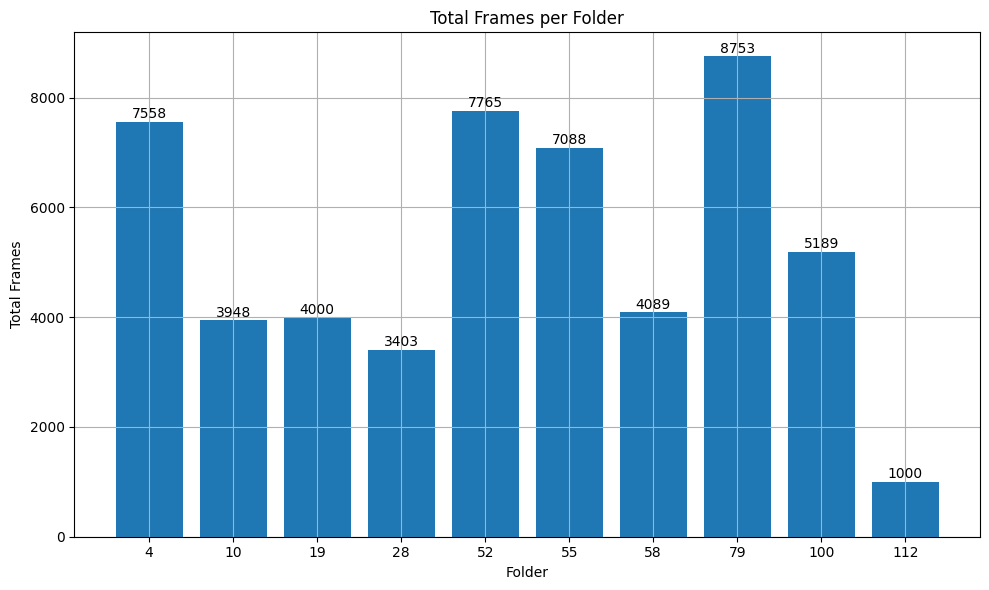

In [1]:
import re
import matplotlib.pyplot as plt
from collections import defaultdict

# List of folders to be analyzed
target_folders = {'4', '10', '19', '28', '52', '55', '58', "79", '100', '112'}
frame_counts = defaultdict(int)

# Read log file
with open(r'E:\Work Spaces\Thesis\Code\ThesisMaster\logs\2025-09-12_22-18-59\log.txt', 'r', encoding='utf-8') as f:
    lines = f.readlines()

# Iterate through each line
for i in range(len(lines) - 1):
    line = lines[i].strip()

    # Match lines that contain input folder path
    match = re.search(r"input\\(\d+)", line)
    if match:
        folder_id = match.group(1)
        if folder_id in target_folders:
            next_line = lines[i + 1].strip()
            # Check if next line contains frame information
            frame_match = re.search(r"the data contains (\d+) frames", next_line)
            if frame_match:
                num_frames = int(frame_match.group(1))
                frame_counts[folder_id] += num_frames

# Plot distribution
plt.figure(figsize=(10, 6))

# Sort folder by number instead of string
folders_sorted = sorted(frame_counts.keys(), key=lambda x: int(x))
values_sorted = [frame_counts[f] for f in folders_sorted]

bars = plt.bar(folders_sorted, values_sorted)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 10, str(height),
             ha='center', va='bottom', fontsize=10)

plt.xlabel("Folder")
plt.ylabel("Total Frames")
plt.title("Total Frames per Folder")
plt.grid(True)
plt.tight_layout()
plt.show()

